<a href="https://colab.research.google.com/github/JUST-ZARI/hotel-clv-prediction/blob/main/notebooks/04_eda_data_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone repository
!git clone https://github.com/JUST-ZARI/hotel-clv-prediction.git
%cd /content/hotel-clv-prediction

Cloning into 'hotel-clv-prediction'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 188 (delta 62), reused 89 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (188/188), 5.56 MiB | 2.87 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/content/hotel-clv-prediction


# Step 4: EDA + Data Quality Check on the Merged Dataset



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Fixed path from absolute '/data/...' to relative 'data/...'
df = pd.read_csv("data/processed/merged_dataset.csv")
print("Shape:", df.shape)
df.head(3)

/tmp/ipykernel_2657/2047252813.py:10: DtypeWarning: Columns (0,12,14,19,21,25,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/processed/merged_dataset.csv")


Shape: (155665, 33)


,hotel_type,is_canceled,lead_time,arrival_year,arrival_month,arrival_day,stays_weekend_nights,stays_week_nights,num_adults,num_children,num_babies,meal_plan,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,room_type_reserved,assigned_room_type,booking_changes,deposit_type,agent_id,company_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_special_requests,reservation_status,reservation_status_date,source_dataset,booking_id
0,Resort Hotel,0,342,2015,7,1,0,0,2,0,0.0,BB,PRT,Direct,Direct,0,0,0,C,C,3.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0,0,Check-Out,2015-07-01,hotel_bookings_2015_2017,NaN
1,Resort Hotel,0,737,2015,7,1,0,0,2,0,0.0,BB,PRT,Direct,Direct,0,0,0,C,C,4.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0,0,Check-Out,2015-07-01,hotel_bookings_2015_2017,NaN
2,Resort Hotel,0,7,2015,7,1,0,1,1,0,0.0,BB,GBR,Direct,Direct,0,0,0,A,C,0.0,No Deposit,NaN,NaN,0.0,Transient,75.0,0,0,Check-Out,2015-07-02,hotel_bookings_2015_2017,NaN


## 1. Dtypes

In [ ]:
df.dtypes

hotel_type                            str
is_canceled                         int64
lead_time                           int64
arrival_year                        int64
arrival_month                       int64
arrival_day                         int64
stays_weekend_nights                int64
stays_week_nights                   int64
num_adults                          int64
num_children                        int64
num_babies                        float64
meal_plan                             str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
room_type_reserved                    str
assigned_room_type                    str
booking_changes                   float64
deposit_type                          str
agent_id                          float64
company_id                        

## 2. Missing values

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
company_id,148868,95.6
booking_id,119390,76.7
agent_id,52615,33.8
country,36763,23.6
hotel_type,36275,23.3
booking_changes,36275,23.3
num_babies,36275,23.3
distribution_channel,36275,23.3
deposit_type,36275,23.3
assigned_room_type,36275,23.3


Expect the 13 Dataset-1-only columns (`country`, `agent_id`, `deposit_type`, etc.) near ~23% missing (36,275 / 155,665 Dataset 2 rows) and `booking_id` near ~77% missing (119,390 / 155,665 Dataset 1 rows) — that's structural, from the merge, not bad data.

## 3. Duplicates

In [7]:
print("Full-row duplicates:", df.duplicated().sum())
# exclude source_dataset/booking_id when checking, since those make every row 'unique' trivially
check_cols = [c for c in df.columns if c not in ('source_dataset', 'booking_id')]
print("Duplicates ignoring source_dataset/booking_id:", df.duplicated(subset=check_cols).sum())

Full-row duplicates: 31994
Duplicates ignoring source_dataset/booking_id: 42269


## 4. Descriptive statistics

In [8]:
df.describe()

,is_canceled,lead_time,arrival_year,arrival_month,arrival_day,stays_weekend_nights,stays_week_nights,num_adults,num_children,num_babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent_id,company_id,days_in_waiting_list,adr,required_car_parking_spaces,total_special_requests
count,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,119390.000000,155665.000000,155665.000000,155665.000000,119390.000000,103050.000000,6797.000000,119390.000000,155665.000000,155665.000000,155665.000000
mean,0.360447,99.635332,2016.544291,6.755494,15.751344,0.900363,2.431324,1.853737,0.104211,0.007949,0.030450,0.072258,0.140899,0.221124,86.693382,189.266735,2.321149,102.202207,0.055170,0.582617
std,0.480132,102.675540,0.955523,3.107693,8.771820,0.971556,1.809001,0.565750,0.399512,0.097436,0.171823,0.760996,1.561051,0.652306,110.774548,131.655015,17.594721,47.393049,0.230914,0.791535
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,4.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,73.000000,0.000000,0.000000
50%,0.000000,66.000000,2016.000000,7.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,153.000000,2017.000000,9.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,125.000000,0.000000,1.000000
max,1.000000,737.000000,2018.000000,12.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [9]:
df.describe(include='object')

,hotel_type,meal_plan,country,market_segment,distribution_channel,room_type_reserved,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,source_dataset,booking_id
count,119390,155665,118902,155665,119390,155665,119390,119390,119390,119390,119390,155665,36275
unique,2,9,177,10,5,17,12,3,4,3,926,2,36275
top,City Hotel,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,hotel_bookings_2015_2017,INN36275
freq,79330,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,119390,1


## 5. Univariate analysis — ADR and lead_time distributions

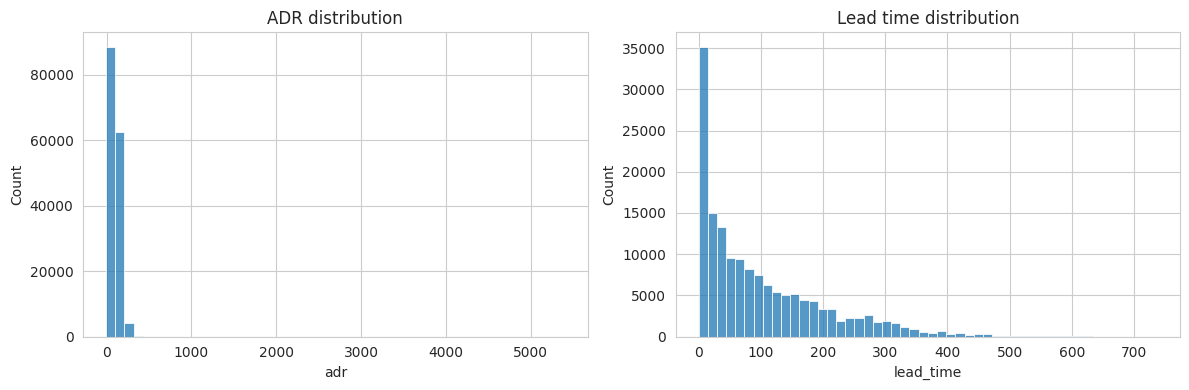

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['adr'], bins=50, ax=axes[0])
axes[0].set_title('ADR distribution')
sns.histplot(df['lead_time'], bins=50, ax=axes[1])
axes[1].set_title('Lead time distribution')
plt.tight_layout()
plt.show()

## 6. Outlier check — ADR and lead_time (IQR method)

In [11]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['adr', 'lead_time']:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: IQR bounds [{low:.1f}, {high:.1f}] -> {n_outliers} outliers "
          f"({n_outliers/len(df)*100:.1f}%), max value = {df[col].max()}")

adr: IQR bounds [-5.0, 203.0] -> 5133 outliers (3.3%), max value = 5400.0
lead_time: IQR bounds [-184.5, 355.5] -> 3873 outliers (2.5%), max value = 737


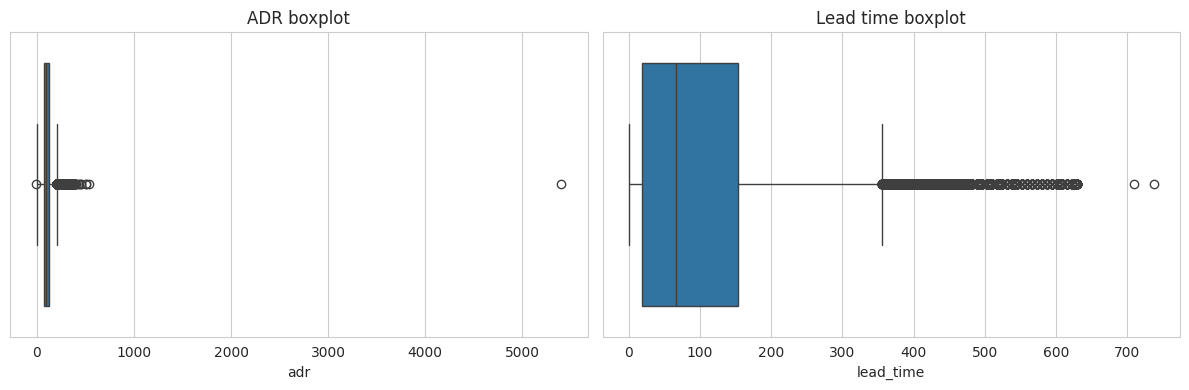

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['adr'], ax=axes[0])
axes[0].set_title('ADR boxplot')
sns.boxplot(x=df['lead_time'], ax=axes[1])
axes[1].set_title('Lead time boxplot')
plt.tight_layout()
plt.show()

In [13]:
# quick look at the most extreme ADR rows - is it a data entry error or a real luxury booking?
df.nlargest(5, 'adr')[['adr', 'hotel_type', 'source_dataset', 'num_adults', 'room_type_reserved']]

,adr,hotel_type,source_dataset,num_adults,room_type_reserved
48515,5400.0,City Hotel,hotel_bookings_2015_2017,2,A
152504,540.0,NaN,hotel_reservations_2017_2018,2,Room_Type 1
111403,510.0,City Hotel,hotel_bookings_2015_2017,1,A
15083,508.0,Resort Hotel,hotel_bookings_2015_2017,2,A
103912,451.5,City Hotel,hotel_bookings_2015_2017,2,E


## 7. Bivariate — is_canceled vs lead_time and ADR

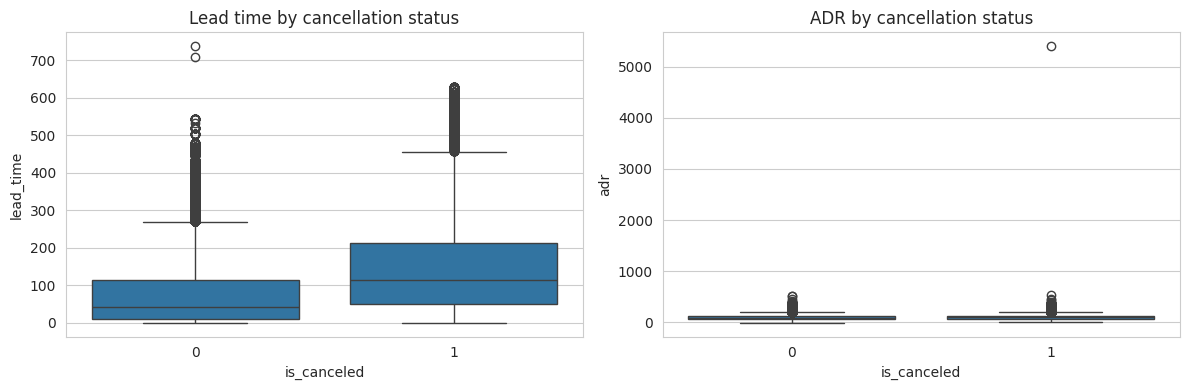

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='is_canceled', y='lead_time', ax=axes[0])
axes[0].set_title('Lead time by cancellation status')
sns.boxplot(data=df, x='is_canceled', y='adr', ax=axes[1])
axes[1].set_title('ADR by cancellation status')
plt.tight_layout()
plt.show()

## 8. Correlation — numeric features

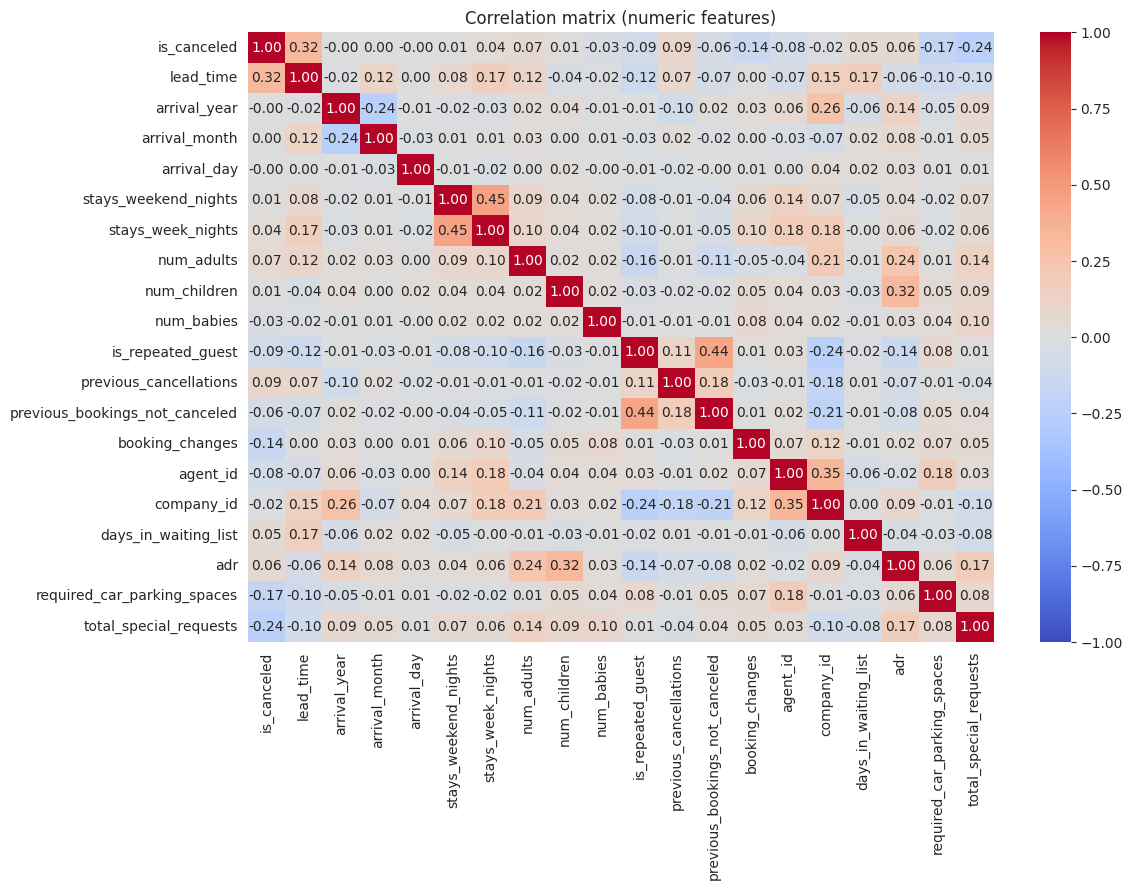

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

In [16]:
# strongest correlations with is_canceled specifically, since that feeds CLV (non-cancelled bookings only)
corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

,is_canceled
lead_time,0.321862
total_special_requests,-0.239543
required_car_parking_spaces,-0.172758
booking_changes,-0.144381
previous_cancellations,0.091878
is_repeated_guest,-0.088812
agent_id,-0.083114
num_adults,0.065880
adr,0.062629
previous_bookings_not_canceled,-0.058015
